## Model 2: Encoder-Decoder (separate RNNs, no attention)


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

from data_prep import load_split_data, device, MAX_LENGTH, SOS_token, EOS_token, PAD_token, UNK_token, RANDOM_STATE
from train_utils import train, plot_losses, evaluateRandomly, compute_bleu, save_result, count_parameters, perplexity, measure_inference_latency

import torch
import torch.nn as nn
import torch.nn.functional as F

print(f"device = {device} | random_state = {RANDOM_STATE}")

device = cpu | random_state = 20


In [2]:
data = load_split_data(batch_size=64)
input_lang, output_lang = data["input_lang"], data["output_lang"]
train_pairs, val_pairs, test_pairs = data["train_pairs"], data["val_pairs"], data["test_pairs"]
train_loader, val_loader = data["train_loader"], data["val_loader"]

Read 331266 sentence pairs
Trimmed to 271824 pairs (< 10 tokens/sentence)
Sampled subset (random_state=20): 8000 pairs
Vocab sizes -> deu: 5743 words | eng: 4028 words
Train: 6400 | Val: 800 | Test: 800


In [3]:
class EncoderRNN(nn.Module):
    """Reads the source sentence, returns per-step outputs + final hidden state
    (the 'context vector' the decoder is initialized with)."""
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded)
        return output, hidden


class DecoderRNN(nn.Module):
    """Generates the target sentence one token at a time, starting from SOS,
    seeded with the encoder's final hidden state."""
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)   # teacher forcing
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()          # greedy decoding

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return F.log_softmax(decoder_outputs, dim=-1), decoder_hidden, None

    def forward_step(self, input, hidden):
        output = F.relu(self.embedding(input))
        output, hidden = self.rnn(output, hidden)
        output = self.out(output)
        return output, hidden

In [4]:
hidden_size = 128
EPOCHS = 40

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

n_params = count_parameters(encoder, decoder)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 1,836,348


In [5]:
train_losses, val_losses = train(train_loader, val_loader, encoder, decoder,
                                  EPOCHS, learning_rate=0.001, print_every=5)

0m 3s (- 2m 9s) (epoch 1/40) train_loss=5.7539 val_loss=5.1480
0m 12s (- 1m 26s) (epoch 5/40) train_loss=4.2285 val_loss=4.3446
0m 23s (- 1m 10s) (epoch 10/40) train_loss=3.4662 val_loss=3.9812
0m 35s (- 0m 59s) (epoch 15/40) train_loss=3.0022 val_loss=3.8937
0m 47s (- 0m 47s) (epoch 20/40) train_loss=2.6332 val_loss=3.9048
1m 0s (- 0m 36s) (epoch 25/40) train_loss=2.3233 val_loss=3.9416
1m 13s (- 0m 24s) (epoch 30/40) train_loss=2.0750 val_loss=4.0106
1m 26s (- 0m 12s) (epoch 35/40) train_loss=1.8702 val_loss=4.0891
1m 46s (- 0m 0s) (epoch 40/40) train_loss=1.7048 val_loss=4.1808


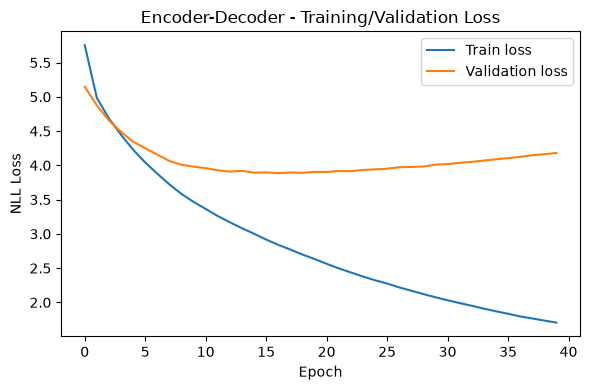

In [6]:
plot_losses(train_losses, val_losses, "Encoder-Decoder - Training/Validation Loss",
            save_path="../outputs/figures/02_encdec_loss.png")

In [7]:
evaluateRandomly(encoder, decoder, test_pairs, input_lang, output_lang, n=10, seed=RANDOM_STATE)

> was ist heutzutage nur mit den kindern los ?
= what s going on with children these days ?
< how many cats do you want to go home ?

> ist das wirklich alles ?
= is that really all ?
< is your mother i don t you ?

> hast du pfannkuchen gegessen ?
= did you have pancakes ?
< why didn t you know that s name ?

> ich akzeptiere deine bedingungen
= i accept your terms
< tom and mary are disappointed in boston

> er ist hier gestern heil angekommen
= he arrived here safely yesterday
< tom said he didn t want to help

> viele sind skeptisch
= many people are skeptical
< you should ve done that this afternoon

> legen sie ihm handschellen an
= cuff him
< don t tell tom did you like

> tom zog die vorhange zu ehe er sich entkleidete
= tom closed the curtains before he got undressed
< tom and mary are very stupid

> ich wei noch wie wutend du mich gemacht hast
= i remember how angry you made me
< i m glad you re doing that

> dieses pedal ist schwergangig
= this pedal is stiff
< you can t bla

In [8]:
bleu = compute_bleu(encoder, decoder, test_pairs, input_lang, output_lang)
print(f"Corpus BLEU-4 (test set, n={len(test_pairs)}): {bleu:.4f}")

Corpus BLEU-4 (test set, n=800): 0.0114


In [9]:

train_ppl = perplexity(train_losses[-1])
val_ppl = perplexity(val_losses[-1])
best_val_ppl = perplexity(min(val_losses))
print(f"Perplexity -> train: {train_ppl:.2f} | val: {val_ppl:.2f} | best val: {best_val_ppl:.2f}")

avg_latency_ms, throughput = measure_inference_latency(encoder, decoder, test_pairs, input_lang, output_lang, n=100)
print(f"Inference latency: {avg_latency_ms:.2f} ms/sentence | Throughput: {throughput:.1f} sentences/sec")

Perplexity -> train: 5.50 | val: 65.42 | best val: 48.74
Inference latency: 1.94 ms/sentence | Throughput: 516.2 sentences/sec


In [10]:
save_result("02_Encoder_Decoder", {
    "architecture": "Encoder-Decoder (separate Encoder/Decoder RNNs, no attention)",
    "hidden_size": hidden_size, "batch_size": 64, "epochs": EPOCHS,
    "trainable_params": n_params,
    "final_train_loss": train_losses[-1], "final_val_loss": val_losses[-1],
    "train_losses": train_losses, "val_losses": val_losses,
    "test_bleu": bleu, "test_set_size": len(test_pairs),
    "train_perplexity": train_ppl,
    "val_perplexity": val_ppl,
    "best_val_perplexity": best_val_ppl,
    "avg_inference_latency_ms": avg_latency_ms,
    "inference_throughput_sentences_per_sec": throughput
})

Saved results for '02_Encoder_Decoder' -> d:\NMT_F\nmt-comparison\src\..\outputs\results.json


### Discussion & Conclusion

The Encoder-Decoder model (separate Encoder and Decoder RNNs) was trained for 40 epochs under the same conditions as the plain RNN. The training loss decreased steadily from 5.75 at epoch 1 to 1.70 at epoch 40, showing that the model continued learning the training data. However, the validation loss decreased from 5.15 to approximately 3.89 by epoch 15, after which it gradually increased, reaching 4.18 at epoch 40. This indicates that the model began to overfit after around epoch 15, as the training loss continued to decrease while validation performance stopped improving.

The relatively high validation loss and low Corpus BLEU-4 score of 0.0114 on the held-out test set indicate that the model has limited translation quality. However, its BLEU-4 score is slightly higher than that of the plain RNN (0.0114 vs. 0.0100), suggesting a small improvement from using a separate Encoder and Decoder.

Qualitatively, the translations are sometimes grammatically plausible but often unrelated to the source meaning. The Encoder-Decoder model still suffers from the fixed-context-vector bottleneck, where the entire source sentence is compressed into a single representation. Thus, although it provides a modest improvement over the plain RNN, the lack of an attention mechanism remains a major limitation, which the next notebook will address.

